# Fiting Models to Environmental Data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Regression Models

In [181]:
from scipy import stats

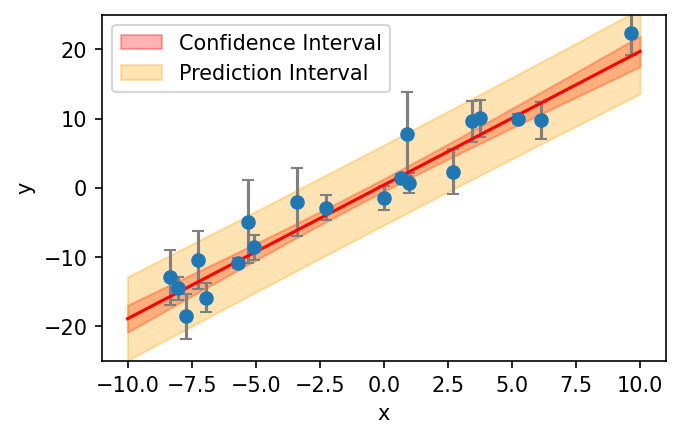

In [ ]:
N = 20

np.random.seed(19)

x = np.random.uniform(-10, 10, N)
y = 2 * x

err = np.random.normal(0, 3, N)

y += err
y_err = np.abs(err) + np.random.normal(0.2, 0.05, N)

x_err = np.random.normal(1, 0.2, N)

# plt.scatter(x, y, zorder=3)
plt.errorbar(x, y, yerr=y_err, fmt='o', ecolor='gray', capsize=3)
# plt.errorbar(x, y, yerr=y_err, xerr=x_err, fmt='o', ecolor='gray', capsize=3)

plt.xlim(-11, 11)
plt.ylim(-25, 25)

plt.xlabel('x')
plt.ylabel('y')

# p, cov = np.polyfit(x, y, 1, cov=True)
p, cov = np.polyfit(x, y, 1, w=1/(y_err**0.5), cov=True)

y_fitted = np.polyval(p, x)
residuals = y - y_fitted
mse = np.var(residuals, ddof=2)  # Mean squared error (with degrees of freedom correction)

nx = np.linspace(-10, 10, 100)

pred = np.polyval(p, nx)
plt.plot(nx, pred, color='red')

pred_var = np.diag(np.dot(np.dot(np.vander(nx, 2), cov), np.vander(nx, 2).T))
pred_std = np.sqrt(pred_var)
plt.fill_between(nx, pred - 1.96 * pred_std, pred + 1.96 * pred_std, color='red', alpha=0.3, label='Confidence Interval')

pred_var_prediction = pred_var + mse
pred_std_prediction = np.sqrt(pred_var_prediction)
plt.fill_between(nx, pred - 1.96 * pred_std_prediction, pred + 1.96 * pred_std_prediction, color='orange', alpha=0.3, label='Prediction Interval')

plt.legend()


([], [])

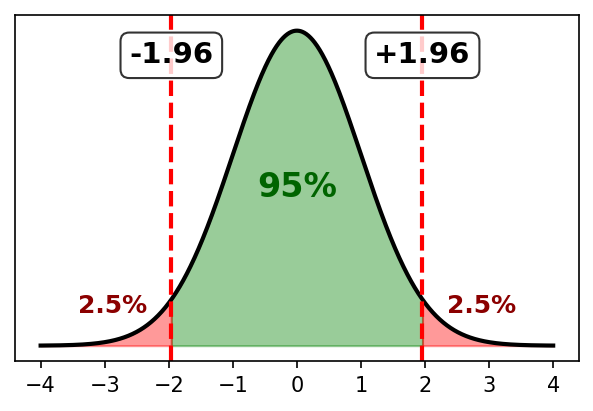

In [159]:
# Single plot showing why 95% CI uses 1.96
from scipy import stats

fig, ax = plt.subplots()

# Standard normal distribution
z = np.linspace(-4, 4, 1000)
pdf = stats.norm.pdf(z, 0, 1)
ax.plot(z, pdf, 'k-', linewidth=2, label='Standard Normal N(0,1)')

# Shade the 95% region (between -1.96 and +1.96)
z_95 = np.linspace(-1.96, 1.96, 200)
pdf_95 = stats.norm.pdf(z_95, 0, 1)
ax.fill_between(z_95, pdf_95, alpha=0.4, color='green', label='95% of area (0.95)')

# Shade the left tail (2.5%)
z_left = np.linspace(-4, -1.96, 100)
pdf_left = stats.norm.pdf(z_left, 0, 1)
ax.fill_between(z_left, pdf_left, alpha=0.4, color='red', label='2.5% in each tail')

# Shade the right tail (2.5%)
z_right = np.linspace(1.96, 4, 100)
pdf_right = stats.norm.pdf(z_right, 0, 1)
ax.fill_between(z_right, pdf_right, alpha=0.4, color='red')

# Mark the critical values
ax.axvline(-1.96, color='red', linestyle='--', linewidth=2)
ax.axvline(1.96, color='red', linestyle='--', linewidth=2)

# Add labels
ax.text(-1.96, 0.35, '-1.96', ha='center', va='bottom', fontsize=14, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.text(1.96, 0.35, '+1.96', ha='center', va='bottom', fontsize=14, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.text(0, 0.2, '95%', ha='center', va='center', fontsize=16, fontweight='bold', color='darkgreen')
ax.text(-2.88, 0.05, '2.5%', ha='center', va='center', fontsize=12, fontweight='bold', color='darkred')
ax.text(2.88, 0.05, '2.5%', ha='center', va='center', fontsize=12, fontweight='bold', color='darkred')

plt.yticks([])

Text(0, 0.5, 'y')

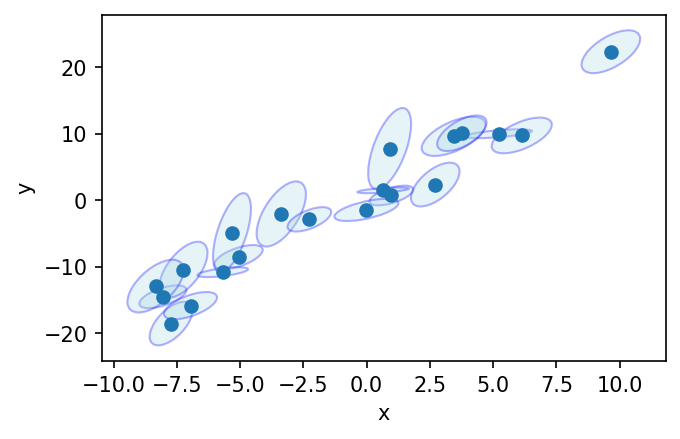

In [160]:
# Much simpler approach:

from matplotlib.patches import Ellipse
from scipy.stats import chi2

def plot_error_ellipse(x, y, xerr, yerr, correlation=0.0, ax=None, **kwargs):
    """Plot error ellipses for correlated x,y errors"""
    if ax is None:
        ax = plt.gca()
    
    for i in range(len(x)):
        # Covariance matrix
        cov = np.array([[xerr[i]**2, correlation * xerr[i] * yerr[i]],
                       [correlation * xerr[i] * yerr[i], yerr[i]**2]])
        
        # Eigenvalues and eigenvectors
        eigenvals, eigenvecs = np.linalg.eig(cov)
        angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
        
        # 1-sigma ellipse
        width = 2 * np.sqrt(eigenvals[0])
        height = 2 * np.sqrt(eigenvals[1])
        
        ellipse = Ellipse((x[i], y[i]), width, height, angle=angle, **kwargs)
        ax.add_patch(ellipse)

# Usage:
fig, ax = plt.subplots()
ax.scatter(x, y, zorder=5)
plot_error_ellipse(x, y, x_err, y_err, correlation=0.6, 
                  alpha=0.3, facecolor='lightblue', edgecolor='blue')

plt.xlabel('x')
plt.ylabel('y')


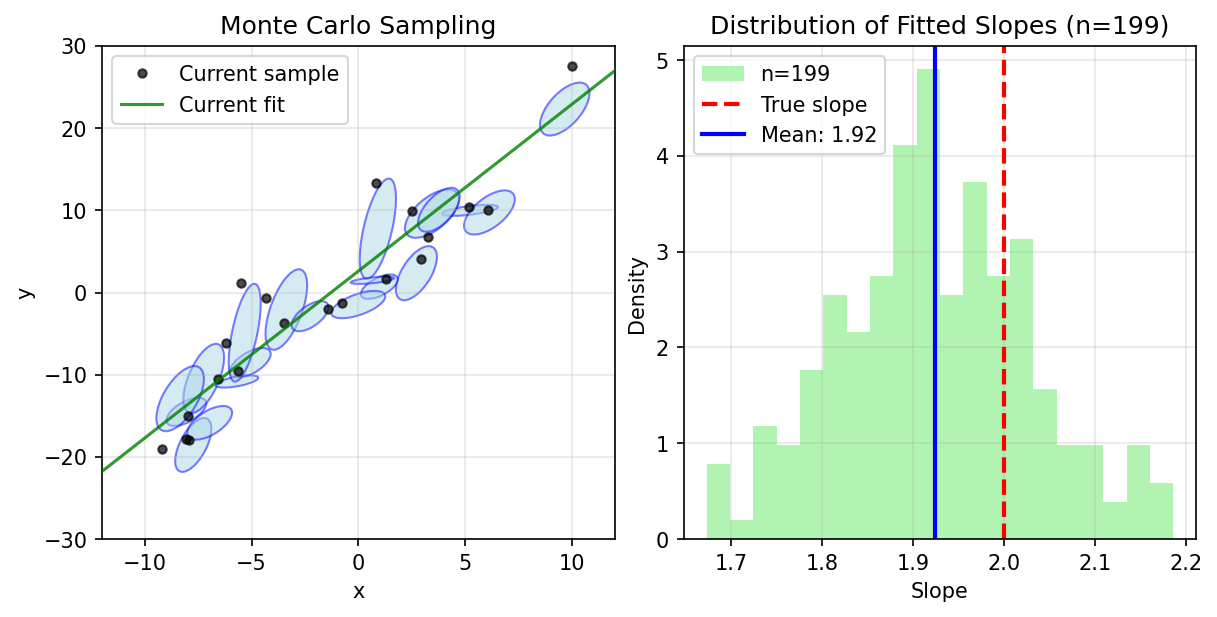

In [ ]:
# Monte Carlo animation through error ellipses
import matplotlib.animation as animation

# Set up the data with correlated errors
np.random.seed(19)
correlation = 0.6

# Store all Monte Carlo results
n_iterations = 200
slopes = []
intercepts = []
all_x_samples = []
all_y_samples = []

# Pre-generate all samples for animation
for i in range(n_iterations):
    # Sample from error ellipses
    x_sample = np.zeros(N)
    y_sample = np.zeros(N)
    
    for j in range(N):
        # Individual point covariance
        point_cov = np.array([[x_err[j]**2, correlation * x_err[j] * y_err[j]],
                             [correlation * x_err[j] * y_err[j], y_err[j]**2]])
        
        # Sample from this point's error ellipse
        sample = np.random.multivariate_normal([x[j], y[j]], point_cov)
        x_sample[j] = sample[0]
        y_sample[j] = sample[1]
    
    # Fit line to this sample
    p_sample = np.polyfit(x_sample, y_sample, 1)
    slopes.append(p_sample[0])
    intercepts.append(p_sample[1])
    all_x_samples.append(x_sample.copy())
    all_y_samples.append(y_sample.copy())

# Create the animation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)

# Set up the main plot
ax1.set_xlim(-12, 12)
ax1.set_ylim(-30, 30)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Monte Carlo Sampling')
ax1.grid(True, alpha=0.3)

# Plot original data and error ellipses
# ax1.scatter(x, y, zorder=10, label='True data')
plot_error_ellipse(x, y, x_err, y_err, correlation=correlation, ax=ax1,
                  alpha=0.5, facecolor='lightblue', edgecolor='blue')

# Set up histogram plot
ax2.set_xlabel('Slope')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Fitted Slopes')
ax2.grid(True, alpha=0.3)
ax2.axvline(2.0, color='red', linestyle='--', linewidth=2, label='True slope')

# Animation elements
current_points, = ax1.plot([], [], 'ko', markersize=4, alpha=0.7, label='Current sample', zorder=99)
current_line, = ax1.plot([], [], 'g-', linewidth=1.5, alpha=0.8, label='Current fit', zorder=99)
family_lines = []  # Will store previous fits

def animate(frame):
    # Clear previous current sample and line
    current_points.set_data([], [])
    current_line.set_data([], [])
    
    # Remove old family lines
    for line in family_lines:
        line.remove()
    family_lines.clear()
    
    if frame < len(all_x_samples):
        # Get current sample
        x_curr = all_x_samples[frame]
        y_curr = all_y_samples[frame]
        slope_curr = slopes[frame]
        intercept_curr = intercepts[frame]
        
        # Update current sample points
        current_points.set_data(x_curr, y_curr)
        
        # Update current fit line
        x_line = np.linspace(-12, 12, 100)
        y_line = intercept_curr + slope_curr * x_line
        current_line.set_data(x_line, y_line)
        
        # Only show last 50 lines for performance
        start_idx = max(0, frame - 50)
        for i in range(start_idx, frame):
            # Calculate alpha based on recency
            recency = (i - start_idx) / max(1, frame - start_idx)
            alpha = 0.1 + 0.4 * recency  # Fade from 0.1 to 0.5
            
            # Plot this historical line
            y_hist = intercepts[i] + slopes[i] * x_line
            line, = ax1.plot(x_line, y_hist, 'gray', linewidth=0.5, alpha=alpha, zorder=1)
            family_lines.append(line)
        
        # Update histogram (same as before)
        if frame > 10:
            ax2.clear()
            ax2.hist(slopes[:frame], bins=20, alpha=0.7, color='lightgreen', 
                    density=True, label=f'n={frame}')
            ax2.axvline(2.0, color='red', linestyle='--', linewidth=2, label='True slope')
            ax2.axvline(np.mean(slopes[:frame]), color='blue', linestyle='-', 
                       linewidth=2, label=f'Mean: {np.mean(slopes[:frame]):.2f}')
            ax2.set_xlabel('Slope')
            ax2.set_ylabel('Density')
            ax2.set_title(f'Distribution of Fitted Slopes (n={frame})')
            ax2.legend()
            ax2.grid(True, alpha=0.3)
    
    return current_points, current_line

# Create and run animation
ax1.legend()
ani = animation.FuncAnimation(fig, animate, frames=n_iterations, 
                            interval=100, blit=False, repeat=True)

# To save the animation (uncomment if needed):
# ani.save('figs/monte_carlo_regression.gif', writer='pillow', fps=10)

In [176]:
import corner

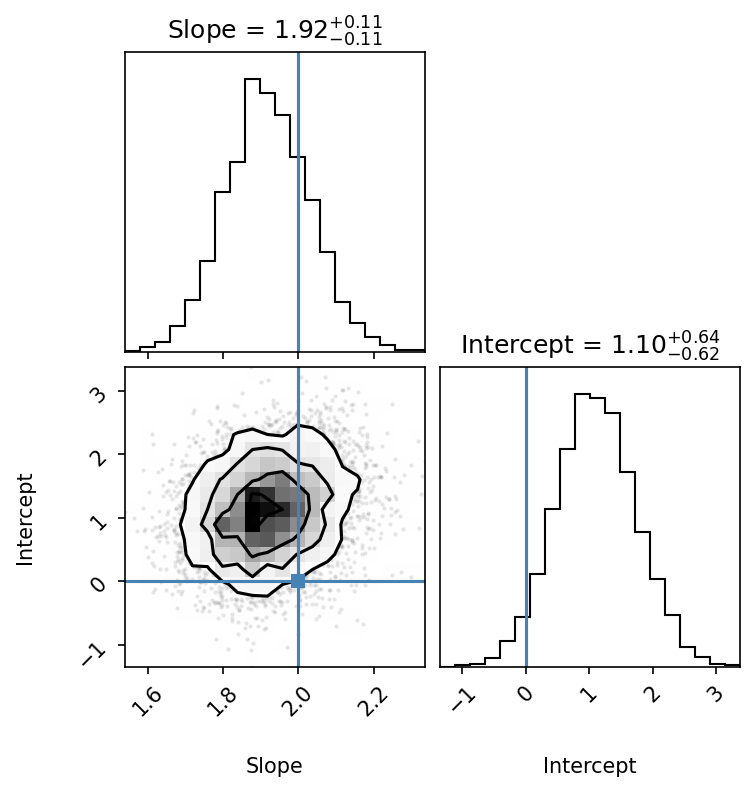

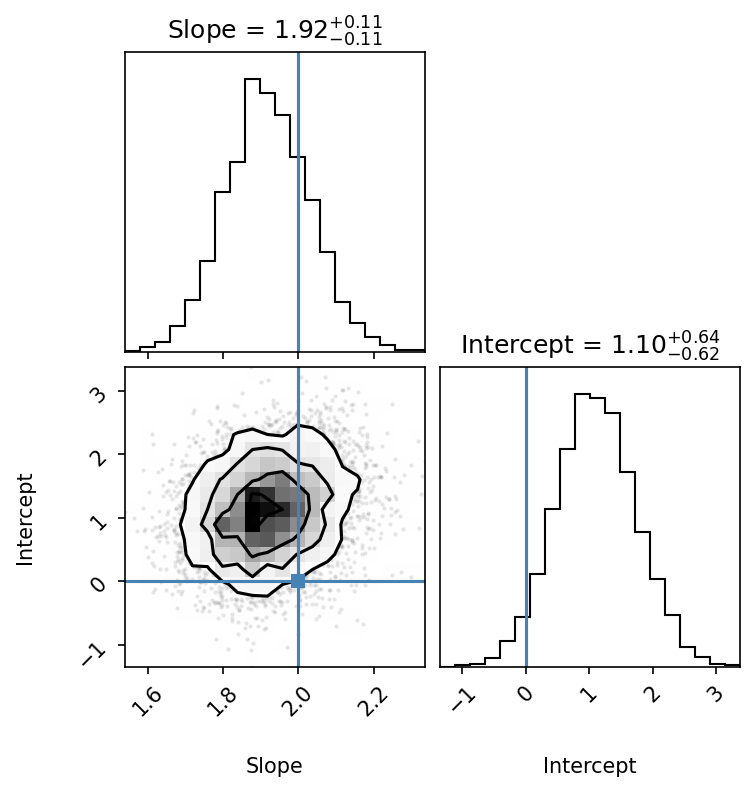

In [ ]:
# Set up the data with correlated errors
np.random.seed(19)
correlation = 0.6

# Store all Monte Carlo results
n_iterations = 6000
slopes = []
intercepts = []
all_x_samples = []
all_y_samples = []

# Pre-generate all samples for animation
for i in range(n_iterations):
    # Sample from error ellipses
    x_sample = np.zeros(N)
    y_sample = np.zeros(N)
    
    for j in range(N):
        # Individual point covariance
        point_cov = np.array([[x_err[j]**2, correlation * x_err[j] * y_err[j]],
                             [correlation * x_err[j] * y_err[j], y_err[j]**2]])
        
        # Sample from this point's error ellipse
        sample = np.random.multivariate_normal([x[j], y[j]], point_cov)
        x_sample[j] = sample[0]
        y_sample[j] = sample[1]
    
    # Fit line to this sample
    p_sample = np.polyfit(x_sample, y_sample, 1)
    slopes.append(p_sample[0])
    intercepts.append(p_sample[1])
    all_x_samples.append(x_sample.copy())
    all_y_samples.append(y_sample.copy())

corner.corner(pd.DataFrame({'slope': slopes, 'intercept': intercepts}), labels=['Slope', 'Intercept'],
              truths=[2.0, 0.0], show_titles=True)``

## Physical Models

In [3]:
data_url = 'https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_daily_mlo.csv'
dat = pd.read_csv(data_url, comment='#', header=None)
# dat = pd.read_csv('data/co2_daily_mlo.csv', comment='#', header=None)  # if working offline, use local file
dat.columns = ['year', 'month', 'day', 'decimal_date', 'pCO2']

In [38]:
volume_of_atmosphere_m3 = 4.2e12  # m^3
moles_of_air = volume_of_atmosphere_m3 * 1.225 / 0.029  # ideal gas law approximation

insolation_w_m2 = 1361  # W/m^2
total_surface_area_m2 = 5.1e14  # m^2

annual_CO2_emissions_mol = 8e12 / 44 * 1e6  # convert from PgC to moles CO2
ocean_uptake_fraction = 0.25  # fraction of emissions taken up by ocean

# northern hemisphere insolation as a function of time
def northern_hemisphere_insolation(decimal_year):
    # approximate using a sine wave
    return 0.5 + 0.5 * np.sin(2 * np.pi * (decimal_year - 0.2))  # peak around day 80 (March 21)

def calc_delta_pCO2(plant_co2_uptake, decimal_year):
    insolation_factor = northern_hemisphere_insolation(decimal_year)
    annual_emission_rate = annual_CO2_emissions_mol / moles_of_air
    ocean_uptake = ocean_uptake_fraction * annual_emission_rate
    plant_uptake = plant_co2_uptake * insolation_factor/ moles_of_air
    delta_pCO2 = annual_emission_rate - ocean_uptake - plant_uptake
    return delta_pCO2

In [261]:
import numpy as np
from scipy.stats import lognorm, norm, uniform

# --- 1. Define the Simulation Parameters ---

# Number of trials (simulations to run)
N_TRIALS = 100000 
# Note: A large number of trials (e.g., 100,000) ensures a stable output distribution.

# --- Input Parameter Distributions ---

# 1. Concentration (C) - Highly skewed, Log-Normal distribution
# We define the mean and standard deviation of the underlying log-transformed data (mu and sigma),
# but often inputs are provided as arithmetic mean (AM) and standard deviation (SD).
# For simplicity, we define the parameters directly based on typical risk assessment inputs:
AM_C = 100.0  # Arithmetic Mean Concentration (mg/kg)
SD_C = 50.0   # Standard Deviation of Concentration (mg/kg)

# Converting AM and SD to Log-Normal parameters (s, loc, scale) for scipy:
# s (shape) relates to the coefficient of variation
# scale is the geometric mean, which is needed for proper sampling
s_c = np.sqrt(np.log(1 + (SD_C/AM_C)**2))
scale_c = AM_C / np.exp(s_c**2 / 2)


# 2. Intake Rate (IR) - Symmetrical, Normal distribution
MU_IR = 0.05  # Mean Intake Rate (kg/day)
SD_IR = 0.01  # Standard Deviation of Intake Rate (kg/day)

# --- 2. Deterministic (Standard) Calculation ---

# This approach uses only the arithmetic mean of the inputs.
dose_standard = AM_C * MU_IR

print("--- Deterministic (Standard) Calculation ---")
print(f"Standard Dose (Mean C * Mean IR): {dose_standard:.2f} mg/day\n")


# --- 3. Monte Carlo Simulation ---

# Step 3a: Draw Random Samples (N_TRIALS for each parameter)

# Sample C from Log-Normal distribution
C_samples = lognorm.rvs(s=s_c, scale=scale_c, size=N_TRIALS)

# Sample IR from Normal distribution
IR_samples = norm.rvs(loc=MU_IR, scale=SD_IR, size=N_TRIALS)

# (Example of other distributions you might sample, though not used here)
# BW_samples = norm.rvs(loc=70, scale=10, size=N_TRIALS)
# EF_samples = uniform.rvs(loc=200, scale=165, size=N_TRIALS) # Uniform from 200 to 365 days/year

# Step 3b: Calculate Output (The Model) for Every Trial
# Since numpy arrays are used, this is a vectorized operation, which is very fast.
Dose_results = C_samples * IR_samples

# Step 3c: Analyze Output Distribution
mc_mean = np.mean(Dose_results)
mc_median = np.median(Dose_results)
mc_p95 = np.percentile(Dose_results, 95)
mc_p99 = np.percentile(Dose_results, 99)

print("--- Monte Carlo (Probabilistic) Calculation ---")
print(f"Total Trials Run: {N_TRIALS}")
print(f"MC Mean Dose:     {mc_mean:.2f} mg/day (This is the average outcome)")
print(f"MC Median Dose:   {mc_median:.2f} mg/day (The 50th percentile)")
print("-" * 35)
print(f"95th Percentile:  {mc_p95:.2f} mg/day (Regulator's RME - 95% of doses are below this)")
print(f"99th Percentile:  {mc_p99:.2f} mg/day (Higher-end risk estimate)")
print("-" * 35)

# --- 4. The Takeaway (Comparing Results) ---
print(f"Difference (MC Mean - Standard Mean): {mc_mean - dose_standard:.2f} mg/day")
print("\nConclusion: Due to the Log-Normal skew in Concentration, the Monte Carlo Mean is higher")
print("than the Standard Mean. The standard approach significantly underestimates the 95th percentile risk.")

# You could also add plotting code here for visualization in a real environment:
# import matplotlib.pyplot as plt
# plt.hist(Dose_results, bins=50)
# plt.axvline(dose_standard, color='red', linestyle='dashed', linewidth=1, label='Standard Mean')
# plt.axvline(mc_mean, color='green', linestyle='dashed', linewidth=1, label='MC Mean')
# plt.legend()
# plt.title("Dose Output Distribution")
# plt.show()


--- Deterministic (Standard) Calculation ---
Standard Dose (Mean C * Mean IR): 5.00 mg/day

--- Monte Carlo (Probabilistic) Calculation ---
Total Trials Run: 100000
MC Mean Dose:     5.00 mg/day (This is the average outcome)
MC Median Dose:   4.39 mg/day (The 50th percentile)
-----------------------------------
95th Percentile:  10.20 mg/day (Regulator's RME - 95% of doses are below this)
99th Percentile:  14.25 mg/day (Higher-end risk estimate)
-----------------------------------
Difference (MC Mean - Standard Mean): -0.00 mg/day

Conclusion: Due to the Log-Normal skew in Concentration, the Monte Carlo Mean is higher
than the Standard Mean. The standard approach significantly underestimates the 95th percentile risk.


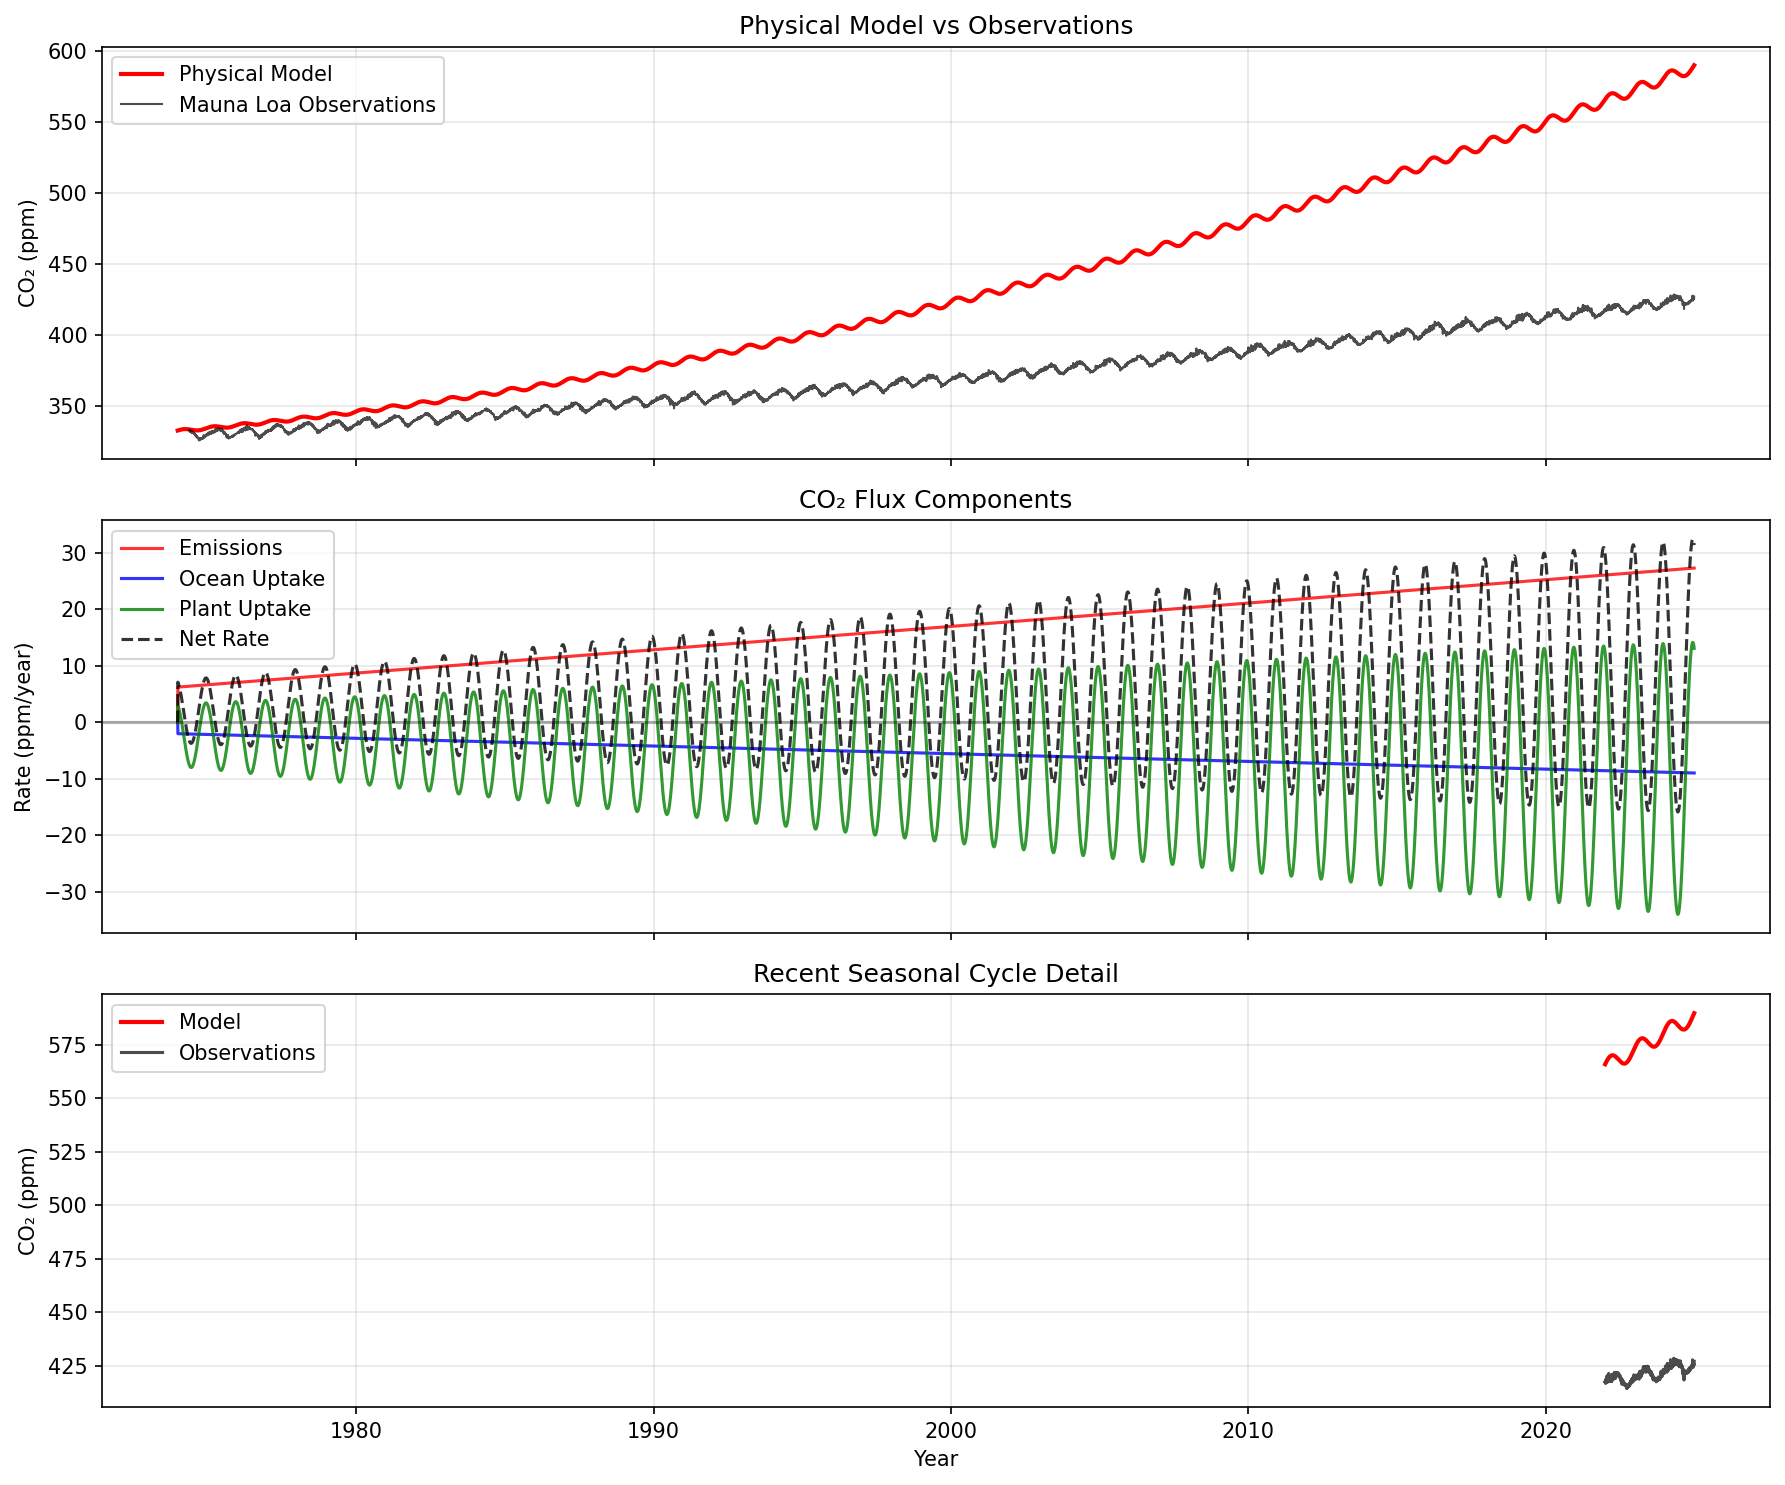

PHYSICAL MODEL SUMMARY
Initial CO₂: 333.0 ppm
Final CO₂: 589.7 ppm
Total increase: 256.7 ppm


AttributeError: 'CO2Model' object has no attribute 'annual_emissions_PgC'

In [74]:
class CO2Model:
    def __init__(self):
        # Atmospheric parameters
        self.total_air_mass_kg = 5.15e18  # kg (total atmospheric mass)
        self.moles_air = self.total_air_mass_kg / 0.029  # kg / (kg/mol)
        
        # Emission parameters
        self.annual_emissions_PgC_1974 = 12.0 * 12 / 40  # PgC/year (anthropogenic)
        
        # Uptake fractions
        self.ocean_uptake_fraction = 0.33
        self.baseline_plant_uptake_fraction = 0.37
        
        # Seasonal parameters
        self.plant_seasonal_amplitude = 4.8  # amplitude of seasonal variation
        self.plant_phase_offset = 0.2  # when photosynthesis peaks (fraction of year)
        
        # Initial conditions
        self.initial_co2_ppm = 333  # starting CO2 concentration
        
    def northern_hemisphere_insolation(self, decimal_year):
        """Normalized solar radiation affecting plant photosynthesis"""
        return 0.5 + 0.5 * np.sin(2 * np.pi * (decimal_year - self.plant_phase_offset))
    
    def calc_annual_sources_sinks(self, decimal_year, year_index=0):
        """Calculate CO2 sources and sinks for a given time"""
        annual_emissions_PgC = self.annual_emissions_PgC_1974 + 0.24 * (decimal_year - 1974)
        annual_emissions_mol = annual_emissions_PgC * 1e15 / 12 * (44/12)  # PgC to mol CO2
        # Annual emissions (constant rate)
        emissions_rate = annual_emissions_mol / self.moles_air * 1e6  # ppm/year
        
        # Ocean uptake (constant fraction of emissions)
        ocean_uptake_rate = self.ocean_uptake_fraction * emissions_rate
        
        # Plant uptake (seasonal, depends on Northern Hemisphere growing season)
        insolation_factor = self.northern_hemisphere_insolation(decimal_year)
        baseline_plant_uptake = self.baseline_plant_uptake_fraction * emissions_rate
        seasonal_plant_uptake = baseline_plant_uptake * (1 + self.plant_seasonal_amplitude * (insolation_factor - 0.5))
        
        # Net rate of change
        net_rate = emissions_rate - ocean_uptake_rate - seasonal_plant_uptake
        
        return {
            'emissions': emissions_rate,
            'ocean_uptake': ocean_uptake_rate, 
            'plant_uptake': seasonal_plant_uptake,
            'net_rate': net_rate
        }
    
    def simulate_co2(self, start_year=1974, end_year=2024):
        """Simulate CO2 concentrations over time"""
        # Create time array
        dt = 1/365  # daily timesteps
        time_years = np.arange(start_year, end_year, dt)
        
        # Initialize arrays
        co2_ppm = np.zeros(len(time_years))
        co2_ppm[0] = self.initial_co2_ppm
        
        # Store components for analysis
        emissions_array = np.zeros(len(time_years))
        ocean_array = np.zeros(len(time_years))
        plant_array = np.zeros(len(time_years))
        
        # Simulate forward in time
        for i in range(1, len(time_years)):
            year = time_years[i]
            year_index = i
            
            # Get sources and sinks
            fluxes = self.calc_annual_sources_sinks(year, year_index)
            
            # Update CO2 concentration (Euler integration)
            co2_ppm[i] = co2_ppm[i-1] + fluxes['net_rate'] * dt
            
            # Store components
            emissions_array[i] = fluxes['emissions']
            ocean_array[i] = fluxes['ocean_uptake'] 
            plant_array[i] = fluxes['plant_uptake']
        
        return {
            'time': time_years,
            'co2_ppm': co2_ppm,
            'emissions': emissions_array,
            'ocean_uptake': ocean_array,
            'plant_uptake': plant_array
        }

# Initialize and run the model
model = CO2Model()
simulation = model.simulate_co2(start_year=1974, end_year=2025)

# Plot results
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Panel 1: CO2 concentrations vs observations
ax1 = axes[0]
ax1.plot(simulation['time'], simulation['co2_ppm'], 'r-', linewidth=2, label='Physical Model')

# Overlay real data
real_data = dat[(dat['year'] >= 1958) & (dat['year'] <= 2024)]
ax1.plot(real_data['decimal_date'], real_data['pCO2'], 'k-', alpha=0.7, linewidth=1, label='Mauna Loa Observations')

ax1.set_ylabel('CO₂ (ppm)')
ax1.set_title('Physical Model vs Observations')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel 2: Individual flux components
ax2 = axes[1]
ax2.plot(simulation['time'], simulation['emissions'], 'r-', label='Emissions', alpha=0.8)
ax2.plot(simulation['time'], -simulation['ocean_uptake'], 'b-', label='Ocean Uptake', alpha=0.8)
ax2.plot(simulation['time'], -simulation['plant_uptake'], 'g-', label='Plant Uptake', alpha=0.8)
ax2.plot(simulation['time'], simulation['emissions'] - simulation['ocean_uptake'] - simulation['plant_uptake'], 
         'k--', label='Net Rate', alpha=0.8)

ax2.set_ylabel('Rate (ppm/year)')
ax2.set_title('CO₂ Flux Components')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axhline(0, color='k', linestyle='-', alpha=0.3)

# Panel 3: Seasonal cycle detail (last 3 years)
ax3 = axes[2]
recent_mask = simulation['time'] >= 2022
ax3.plot(simulation['time'][recent_mask], simulation['co2_ppm'][recent_mask], 'r-', linewidth=2, label='Model')

recent_obs = real_data[real_data['year'] >= 2022]
if len(recent_obs) > 0:
    ax3.plot(recent_obs['decimal_date'], recent_obs['pCO2'], 'k-', alpha=0.7, label='Observations')

ax3.set_ylabel('CO₂ (ppm)')
ax3.set_xlabel('Year')
ax3.set_title('Recent Seasonal Cycle Detail')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print model summary
print("PHYSICAL MODEL SUMMARY")
print("=" * 50)
print(f"Initial CO₂: {model.initial_co2_ppm:.1f} ppm")
print(f"Final CO₂: {simulation['co2_ppm'][-1]:.1f} ppm")
print(f"Total increase: {simulation['co2_ppm'][-1] - model.initial_co2_ppm:.1f} ppm")
print(f"Annual emissions: {model.annual_emissions_PgC:.1f} PgC/year")
print(f"Ocean uptake fraction: {model.ocean_uptake_fraction:.1%}")
print(f"Plant uptake fraction: {model.baseline_plant_uptake_fraction:.1%}")
print(f"Plant seasonal amplitude: {model.plant_seasonal_amplitude:.1%}")